In [42]:
%pylab inline
#code units
Mstar = 1
R0 = 1
G = 1
R_MU = 1

#cgs units
kB_CGS = 1.38064852e-16      # erg / K
mH_CGS = 2.4 * 1.67262192369e-24 # g (μ = 2.4)
Mstar_CGS = 1.9891e33            # g
G_CGS = 6.674e-8
AU_CM = 1.49597871e13
R0_CGS = 40.0 * AU_CM
R_MU_CGS = 36149835.0
gamma = 1.4

# ERGS macro for scale-free fondam (G=MSTAR=R0=1): one code energy unit [erg]
ergs_code = 1/((R0/R0_CGS) / ((G/G_CGS) * (Mstar/Mstar_CGS)**2))
Kelvin_code = ((G*Mstar/R0/R_MU)/(G_CGS*Mstar_CGS/R0_CGS/R_MU_CGS))

# k_B in code units ergs per kelvin
kB_code = kB_CGS * ergs_code/ Kelvin_code

# One particle mass in code units if 1 code mass = one stellar mass
mH_code = mH_CGS * (Mstar/ Mstar_CGS)


print(kB_code/ mH_code)


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
0.9514101616899105


/Users/nadine/venvs/nadine/lib/python3.13/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['gamma']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [43]:
rmin = loadtxt("../../outputs/vsi_128_iso/domain_y.dat")[3:-3]
tmin = loadtxt("../../outputs/vsi_128_iso/domain_z.dat")[3:-3]

rmed = 0.5 * (rmin[1:] + rmin[:-1])
tmed = 0.5 * (tmin[1:] + tmin[:-1])

R, T = meshgrid(rmed, tmed)

nz = 128
ny = 128


-0.016991351806550255


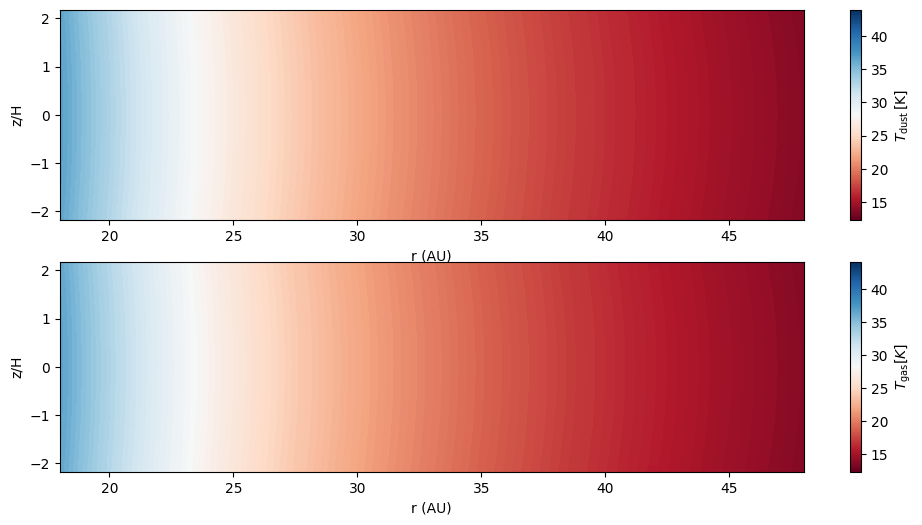

In [44]:
n =6

vthetan_th = fromfile("../../outputs/vsi_128_iso/gasvz{:d}.dat".format(n)).reshape(nz,ny)
rhodn_th = fromfile("../../outputs/vsi_128_iso/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
edn_th = fromfile("../../outputs/vsi_128_iso/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
egn_th = fromfile("../../outputs/vsi_128_iso/gasenergy{:d}.dat".format(n)).reshape(nz,ny)
rhogn_th = fromfile("../../outputs/vsi_128_iso/gasdens{:d}.dat".format(n)).reshape(nz,ny)

# tcol = fromfile("../../outputs/vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = gamma * R_MU /(gamma -1)
cd = 0.088* cg

Tdust = edn_th / rhodn_th / Kelvin_code / cd

Tgas = egn_th / rhogn_th / Kelvin_code / cg

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
print(np.mean(tcol))
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, Tdust, cmap='RdBu')

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T_{\rm dust}\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, Tgas, cmap='RdBu')
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$T_{\rm gas} [K]$')
show()

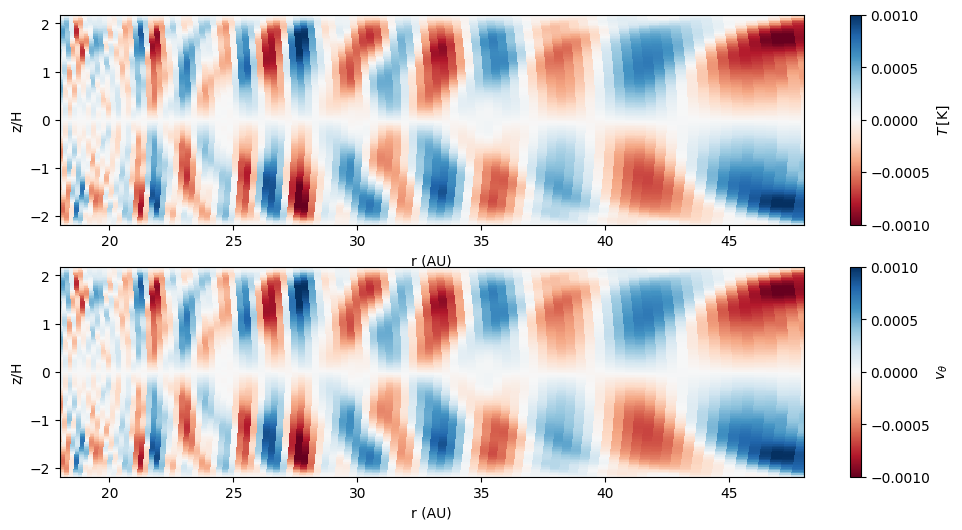

In [45]:
n =38

vthetan_th = fromfile("../../outputs/vsi_128_iso/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_128_iso/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg


H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.001,vmax=0.001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

-48.887794586934966


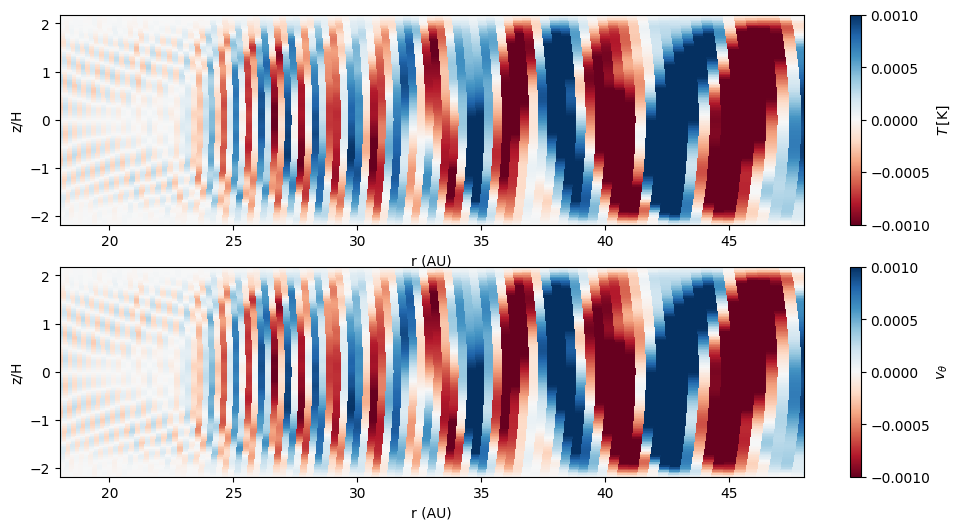

In [47]:
n =100

vthetan_th = fromfile("../../outputs/vsi_128_adi/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_128_adi/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
tcol= fromfile("../../outputs//vsi_128_adi/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg

# Tdust = edn_th / rhodn_th / Kelvin_code / cd

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
print(1/np.mean(tcol))
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.001,vmax=0.001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

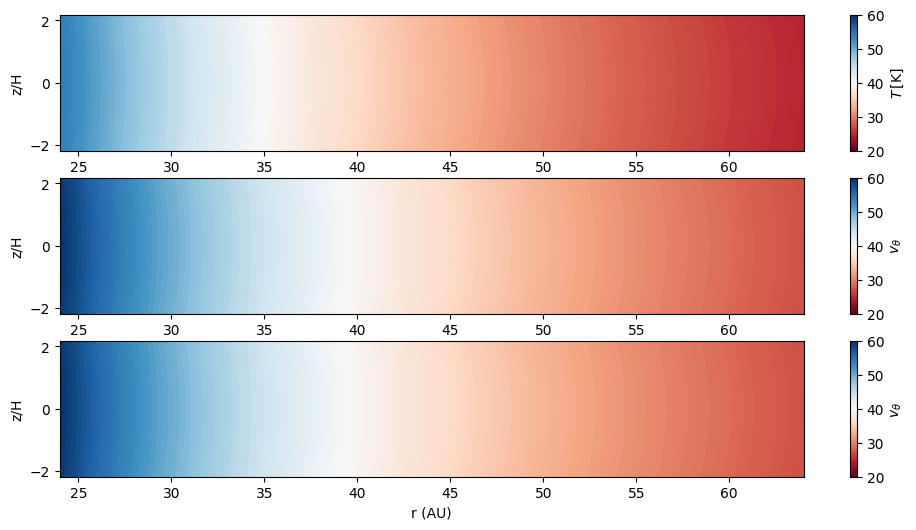

In [84]:
n =0

vthetan_th = fromfile("../../outputs/vsi_sametemp/gasenergy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs/vsi_sametemp/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d2= fromfile("../../outputs/vsi_sametemp/dust2energy{:d}.dat".format(n)).reshape(nz,ny)
cg = 1/(gamma-1)
cd = 0.08 * cg
rho = fromfile("../../outputs/vsi_sametemp/gasdens{:d}.dat".format(n)).reshape(nz,ny)
rhod1= fromfile("../../outputs/vsi_sametemp/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
rhod2= fromfile("../../outputs/vsi_sametemp/dust2dens{:d}.dat".format(n)).reshape(nz,ny)

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(311)
surf1 = ax1.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_th/rho/cg / Kelvin_code, cmap='RdBu',vmin = 20, vmax = 60)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*40, 1.6*40)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

ax2 = fig.add_subplot(312)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d/rhod1/cd/ Kelvin_code, cmap='RdBu', vmin = 20, vmax = 60)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')

ax2 = fig.add_subplot(313)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d2/rhod2/cd/ Kelvin_code, cmap='RdBu', vmin = 20, vmax = 60)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

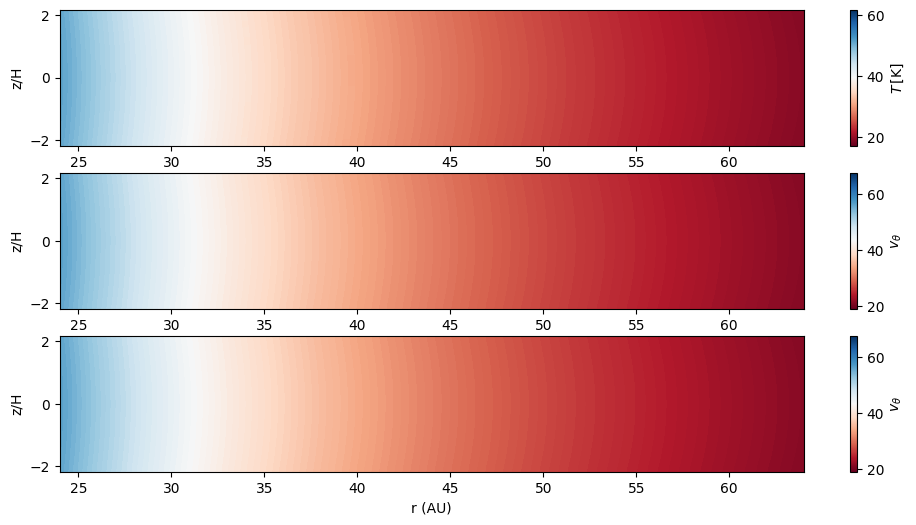

In [81]:
n =78

vthetan_th = fromfile("../../outputs/vsi_128_2fluid/gasenergy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs/vsi_128_2fluid/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d2= fromfile("../../outputs/vsi_128_2fluid/dust2energy{:d}.dat".format(n)).reshape(nz,ny)
cg = 1/(gamma-1)
cd = 0.08 * cg
rho = fromfile("../../outputs/vsi_128_2fluid/gasdens{:d}.dat".format(n)).reshape(nz,ny)
rhod1= fromfile("../../outputs/vsi_128_2fluid/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
rhod2= fromfile("../../outputs/vsi_128_2fluid/dust2dens{:d}.dat".format(n)).reshape(nz,ny)

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(311)
surf1 = ax1.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_th/rho/cg/ Kelvin_code, cmap='RdBu')

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*40, 1.6*40)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

ax2 = fig.add_subplot(312)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d/rhod1/cd/ Kelvin_code, cmap='RdBu')
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')

ax2 = fig.add_subplot(313)
surf2 = ax2.pcolormesh(40*R*sin(T),cos(T)/H0, vthetan_d2/rhod2/cd/ Kelvin_code, cmap='RdBu')
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(40*0.6, 40*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

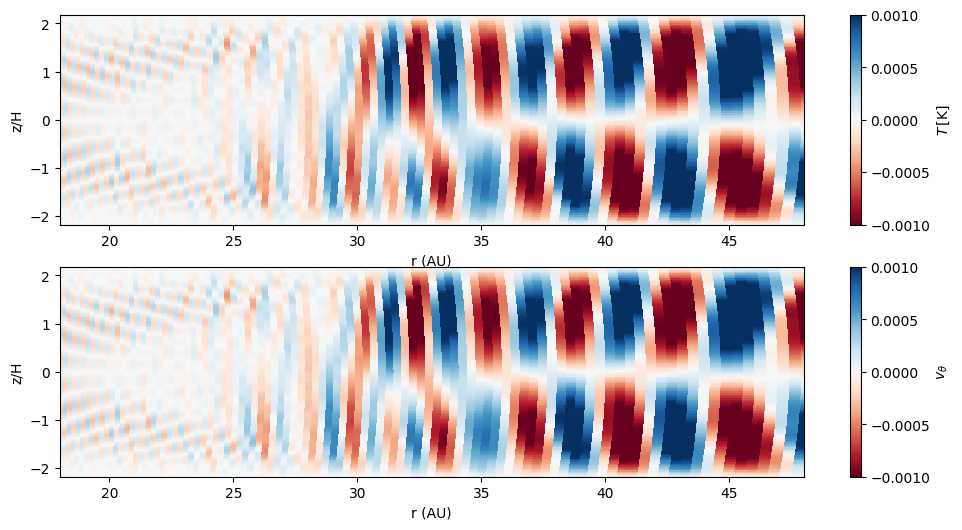

In [58]:
n =78

vthetan_th = fromfile("../../outputs/vsi_128_2fluid/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_128_2fluid/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg


H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.001,vmax=0.001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

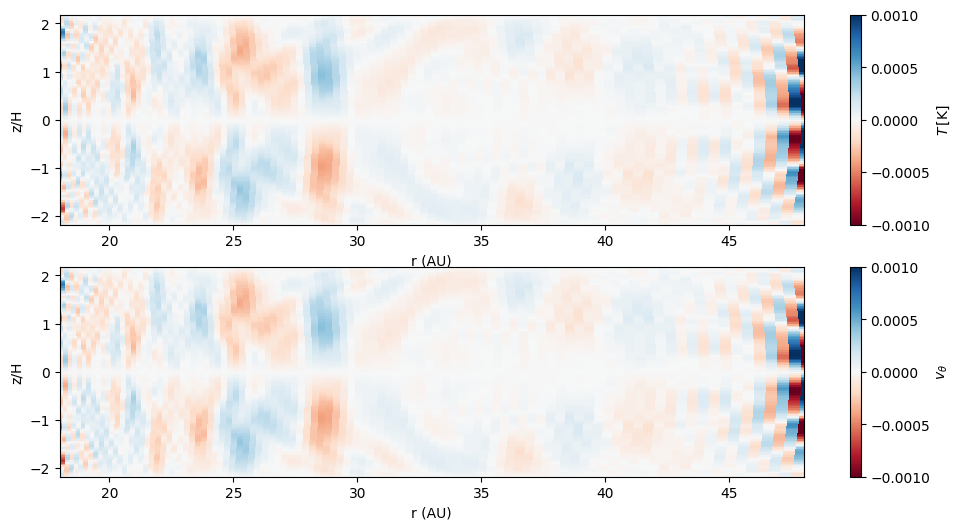

In [59]:
n =78

vthetan_th = fromfile("../../outputs/vsi_sametemp/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_sametemp/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg


H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.001,vmax=0.001)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.001,vmax=0.001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

/var/folders/_0/vjjwsf2n78qf97zssfnywywr0000gn/T/ipykernel_3653/3269527207.py:21: UserWarning: Adding colorbar to a different Figure <Figure size 1200x600 with 4 Axes> than <Figure size 1200x600 with 4 Axes> which fig.colorbar is called on.
  fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')


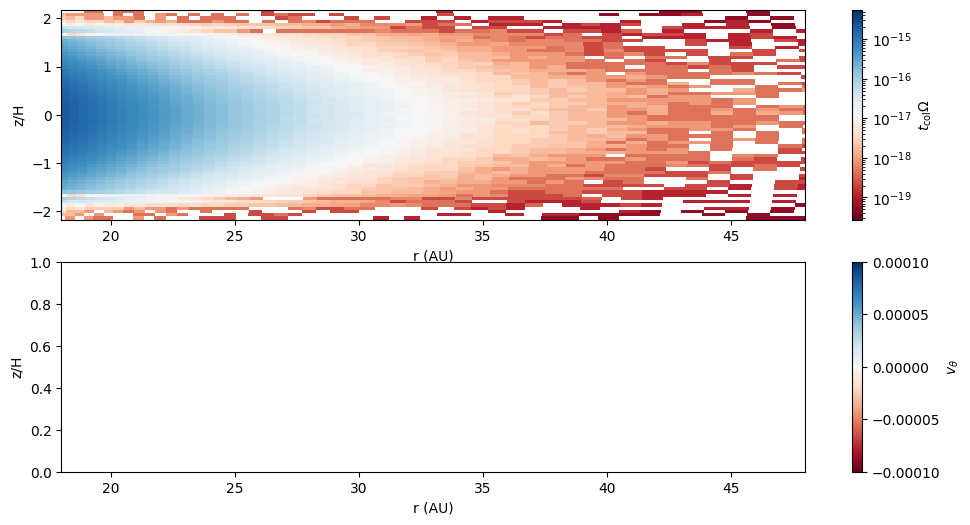

In [49]:
n = 50

tcol = fromfile("../../outputs/vsi_lin/Tcol{:d}.dat".format(n)).reshape(nz,ny)
H0 = 0.06

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm())
ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
# surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.0001,vmax=0.0001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()